# **Crop Yield Prediction Using Satellite Imagery**

**Introduction:**

Agricultural productivity is strongly influenced by environmental conditions such as rainfall, temperature, soil quality, and vegetation health. Accurate yield prediction helps farmers, policymakers, and researchers make better decisions regarding food security and agricultural planning.

With the advancement of satellite remote sensing and machine learning, it has become possible to estimate crop yields using satellite observations of vegetation growth throughout the growing season.

In this project, we develop a deep learning pipeline that predicts soybean yield from satellite imagery time series.

In [9]:
# ============================================
# Install Required Libraries
# ============================================

print(" Installing dependencies...\n")

# Core libraries for deep learning and geospatial data
!pip install -q torchgeo rasterio torch matplotlib numpy scikit-learn tqdm

print(" Installation complete!\n")

# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchgeo.datasets import SustainBenchCropYield
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import numpy as np
import matplotlib.pyplot as plt
import rasterio
import os
import glob
import re
import json
import pickle
from tqdm.auto import tqdm
from google.colab import files

print(" All libraries imported successfully!")

 Installing dependencies...

 Installation complete!

 All libraries imported successfully!


# **Dataset Overview**

This project uses the SustainBench Crop Yield Dataset, which is designed for machine learning research in agricultural sustainability. The dataset combines satellite observations with official crop yield statistics to enable crop yield prediction.

Satellite data is collected from the MODIS Terra, which captures Earth surface conditions such as vegetation growth throughout the crop season. The dataset focuses on soybean-producing regions in United States, Brazil, and Argentina.

Instead of raw images, the dataset provides histogram time-series features derived from satellite bands and vegetation indices like NDVI and EVI. These features capture vegetation distribution and crop growth patterns over time.

The target variable is soybean yield measured in tons per hectare (t/ha), which represents the amount of crop produced per unit of farmland. This dataset enables the development of machine learning models that can predict crop productivity using satellite-based observations.

In [10]:
# ============================================
# Download SustainBench Crop Yield Dataset
# ============================================

print("="*70)
print("   DOWNLOADING SUSTAINBENCH DATASET")
print("="*70)

"""
SustainBench is a benchmark dataset for sustainable development.
It contains:
- Satellite imagery (MODIS) from 2003-2016
- County-level soybean yields for the US
- Pre-processed histogram features (9 bands × 32 bins × 32 timesteps)
"""

# Download dataset
dataset = SustainBenchCropYield(
    root="/content/sustainbench_data",
    download=True
)

print("\n Download complete!")


# Load train/dev/test splits
train_dataset = SustainBenchCropYield(root="/content/sustainbench_data", split="train")
dev_dataset = SustainBenchCropYield(root="/content/sustainbench_data", split="dev")
test_dataset = SustainBenchCropYield(root="/content/sustainbench_data", split="test")

print(f"\n Data splits:")
print(f"   Training:   {len(train_dataset):,} samples")
print(f"   Validation: {len(dev_dataset):,} samples")
print(f"   Test:       {len(test_dataset):,} samples")

   DOWNLOADING SUSTAINBENCH DATASET

 Download complete!

 Data splits:
   Training:   5,792 samples
   Validation: 1,448 samples
   Test:       1,809 samples


In [11]:
# ============================================
# EXPLORE A SAMPLE
# ============================================

print("\n" + "="*70)
print("           EXPLORING THE DATA")
print("="*70)

# Get one sample
sample = train_dataset[100]  # Pick sample #100

# Extract image and label
image = sample['image'].numpy()  # Convert PyTorch tensor to NumPy array
label = sample['label'].item() if hasattr(sample['label'], 'item') else float(sample['label'])

print("\n Sample structure:")
print(f"   Image shape:  {image.shape}")
print(f"   Yield (label): {label:.2f} tons/hectare")
print(f"   Equivalent:    {label / 0.0672:.1f} bushels/acre")

print("\n  What does (9, 32, 32) mean?")
print("   ├─ 9:  Number of spectral bands/features")
print("   ├─ 32: Histogram bins (represents distribution of pixel values)")
print("   └─ 32: Time steps (growing season from April to October)")

print("\n The 9 spectral bands are:")
band_names = ['NDVI', 'EVI', 'Red', 'NIR', 'Blue', 'Green', 'SWIR1', 'SWIR2', 'SWIR3']
for i, name in enumerate(band_names):
    print(f"   {i+1}. {name}")

print("\n Key concept:")
print("   Instead of storing millions of raw pixels, we use HISTOGRAMS.")
print("   Histograms capture the DISTRIBUTION of vegetation across the field.")
print("   This makes the data compact and perfect for deep learning!")


           EXPLORING THE DATA

 Sample structure:
   Image shape:  (9, 32, 32)
   Yield (label): 3.82 tons/hectare
   Equivalent:    56.8 bushels/acre

  What does (9, 32, 32) mean?
   ├─ 9:  Number of spectral bands/features
   ├─ 32: Histogram bins (represents distribution of pixel values)
   └─ 32: Time steps (growing season from April to October)

 The 9 spectral bands are:
   1. NDVI
   2. EVI
   3. Red
   4. NIR
   5. Blue
   6. Green
   7. SWIR1
   8. SWIR2
   9. SWIR3

 Key concept:
   Instead of storing millions of raw pixels, we use HISTOGRAMS.
   Histograms capture the DISTRIBUTION of vegetation across the field.
   This makes the data compact and perfect for deep learning!


# Model Architecture

The model combines spatial feature extraction and temporal pattern learning using a hybrid deep learning architecture.

The architecture includes three main components:

1.CNN (Convolutional Neural Network)

The CNN processes histogram distributions of spectral bands to extract meaningful feature representations.

2.LSTM (Long Short-Term Memory Network)

The LSTM learns temporal dependencies across the growing season, capturing crop growth dynamics.

3.Attention Mechanism

Attention helps the model focus on the most important time periods during the crop development cycle.

The final output is a regression prediction of soybean yield in tons per hectare.

In [12]:
# ============================================
# CNN-LSTM MODEL WITH ATTENTION
# ============================================

print("="*70)
print("   MODEL ARCHITECTURE")
print("="*70)

class HistogramCNN_LSTM(nn.Module):
    """
    Deep Learning Model for Crop Yield Prediction

    Architecture:
    1. CNN: Extracts features from histogram distributions
    2. LSTM: Captures temporal patterns across growing season
    3. Attention: Focuses on critical growth periods (flowering, pod fill)
    4. Regression: Outputs yield prediction

    Input:  (batch, 9, 32, 32) - Histogram time series
    Output: (batch,) - Yield predictions
    """

    def __init__(self, n_bands=9, n_bins=32, n_timesteps=32,
                 cnn_channels=64, lstm_hidden=128, dropout=0.3):
        super().__init__()

        # ========== COMPONENT 1: CNN ==========
        # Processes histogram distributions for each spectral band
        self.histogram_cnn = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # Reduce to single value per band
        )

        # ========== COMPONENT 2: LSTM ==========
        # Captures temporal dependencies (e.g., drought timing)
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            dropout=dropout,
            bidirectional=True  # Look forward AND backward in time
        )

        # ========== COMPONENT 3: ATTENTION ==========
        # Learns which timesteps are most important
        # (e.g., flowering period has high impact on yield)
        self.attention = nn.Sequential(
            nn.Linear(lstm_hidden * 2, lstm_hidden),
            nn.Tanh(),
            nn.Linear(lstm_hidden, 1)
        )

        # ========== COMPONENT 4: REGRESSION HEAD ==========
        # Converts learned features to yield prediction
        self.regressor = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            nn.Linear(128, 1)  # Final yield output
        )

    def forward(self, x):
        """
        Forward pass through the network

        Args:
            x: (batch, 9, 32, 32) histogram tensor

        Returns:
            predictions: (batch,) yield predictions
        """
        batch_size, n_bands, n_bins, n_timesteps = x.shape

        # Step 1: Reshape for CNN processing
        x = x.permute(0, 3, 1, 2)  # (batch, timesteps, bands, bins)
        x = x.reshape(batch_size * n_timesteps, n_bands, n_bins)

        # Step 2: CNN extracts histogram features
        cnn_out = self.histogram_cnn(x)  # (batch*timesteps, 64, 1)
        cnn_out = cnn_out.squeeze(-1).view(batch_size, n_timesteps, -1)

        # Step 3: LSTM models temporal patterns
        lstm_out, _ = self.lstm(cnn_out)  # (batch, timesteps, 256)

        # Step 4: Attention focuses on important timesteps
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = (lstm_out * attn_weights).sum(dim=1)  # Weighted sum

        # Step 5: Regression predicts yield
        output = self.regressor(context)
        return output.squeeze(-1)


# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HistogramCNN_LSTM().to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Model created successfully!")
print(f"   Device: {device}")
print(f"   Total parameters: {n_params:,}")
print(f"\n   Architecture summary:")
print(f"   • CNN:        Extracts spatial features from histograms")
print(f"   • LSTM:       Models temporal patterns (growing season)")
print(f"   • Attention:  Identifies critical growth periods")
print(f"   • Regressor:  Outputs final yield prediction")

   MODEL ARCHITECTURE

 Model created successfully!
   Device: cuda
   Total parameters: 733,826

   Architecture summary:
   • CNN:        Extracts spatial features from histograms
   • LSTM:       Models temporal patterns (growing season)
   • Attention:  Identifies critical growth periods
   • Regressor:  Outputs final yield prediction


# **Training Process**

The model is trained using the SustainBench dataset split into:

Training set
Used to learn model parameters.

Validation (development) set
Used to tune hyperparameters and monitor training performance.

Test set
Used to evaluate final model performance.

The training objective is to minimize mean squared error (MSE) between predicted yield and ground truth yield.

In [13]:
# ============================================
# TRAINING CONFIGURATION
# ============================================

print("\n" + "="*70)
print("   TRAINING SETUP")
print("="*70)

# Hyperparameters
config = {
    'n_epochs': 40,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'batch_size': 64,
    'patience': 15  # Early stopping patience
}

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=config['batch_size'],
                          shuffle=True, num_workers=0)
dev_loader = DataLoader(dev_dataset, batch_size=config['batch_size'],
                        shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'],
                         shuffle=False, num_workers=0)

# Optimizer (AdamW with weight decay for regularization)
optimizer = optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

# Loss function (Huber Loss - robust to outliers)
criterion = nn.HuberLoss(delta=1.0)

# Learning rate scheduler (reduce when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Training history
history = {
    'train_loss': [],
    'dev_loss': [],
    'dev_r2': [],
    'dev_rmse': [],
    'dev_mae': []
}

print(f"\n Configuration:")
for key, value in config.items():
    print(f"   {key:15s}: {value}")

print(f"\n Data loaders:")
print(f"   Train batches: {len(train_loader):,}")
print(f"   Val batches:   {len(dev_loader):,}")
print(f"   Test batches:  {len(test_loader):,}")

# ============================================
# TRAINING LOOP
# ============================================

print("\n" + "="*70)
print("   TRAINING MODEL")
print("="*70)

best_dev_loss = float('inf')
patience_counter = 0

for epoch in range(config['n_epochs']):

    # ========== TRAINING PHASE ==========
    model.train()
    train_losses = []

    for batch in train_loader:
        inputs = batch['image'].to(device)
        targets = batch['label'].to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

    # ========== VALIDATION PHASE ==========
    model.eval()
    dev_preds, dev_targets = [], []

    with torch.no_grad():
        for batch in dev_loader:
            inputs = batch['image'].to(device)
            targets = batch['label']
            outputs = model(inputs)

            dev_preds.extend(outputs.cpu().numpy())
            dev_targets.extend(targets.numpy())

    # Calculate metrics
    dev_preds = np.array(dev_preds)
    dev_targets = np.array(dev_targets)

    dev_rmse = np.sqrt(mean_squared_error(dev_targets, dev_preds))
    dev_mae = mean_absolute_error(dev_targets, dev_preds)
    dev_r2 = r2_score(dev_targets, dev_preds)

    avg_train_loss = np.mean(train_losses)

    # Update history
    history['train_loss'].append(avg_train_loss)
    history['dev_loss'].append(dev_rmse)
    history['dev_r2'].append(dev_r2)
    history['dev_rmse'].append(dev_rmse)
    history['dev_mae'].append(dev_mae)

    # Update learning rate
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(dev_rmse)
    new_lr = optimizer.param_groups[0]['lr']

    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"\nEpoch {epoch+1}/{config['n_epochs']}:")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Dev RMSE:   {dev_rmse:.4f}")
        print(f"  Dev MAE:    {dev_mae:.4f}")
        print(f"  Dev R²:     {dev_r2:.4f}")

        if new_lr < old_lr:
            print(f"   LR reduced: {old_lr:.6f} → {new_lr:.6f}")

    # Save best model
    if dev_rmse < best_dev_loss:
        best_dev_loss = dev_rmse
        patience_counter = 0

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'dev_r2': dev_r2,
            'dev_rmse': dev_rmse,
            'dev_mae': dev_mae,
            'history': history,
            'config': config,
            'data_format': {'format_type': 'histogram', 'n_bands': 9,
                          'n_bins': 32, 'n_timesteps': 32}
        }

        torch.save(checkpoint, 'best_sustainbench_model.pth')

        if (epoch + 1) % 5 == 0:
            print(f"   Best model saved! (RMSE: {best_dev_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= config['patience']:
            print(f"\n Early stopping at epoch {epoch+1}")
            break

print("\n" + "="*70)
print("   TRAINING COMPLETE!")
print("="*70)
print(f"Best Dev RMSE: {best_dev_loss:.4f}")
print(f"Best Dev R²:   {max(history['dev_r2']):.4f}")


   TRAINING SETUP

 Configuration:
   n_epochs       : 40
   learning_rate  : 0.001
   weight_decay   : 0.0001
   batch_size     : 64
   patience       : 15

 Data loaders:
   Train batches: 91
   Val batches:   23
   Test batches:  29

   TRAINING MODEL

Epoch 1/40:
  Train Loss: 2.1414
  Dev RMSE:   1.1713
  Dev MAE:    0.9795
  Dev R²:     -1.9040

Epoch 5/40:
  Train Loss: 0.2861
  Dev RMSE:   1.0948
  Dev MAE:    0.9735
  Dev R²:     -1.5370

Epoch 10/40:
  Train Loss: 0.1748
  Dev RMSE:   0.9078
  Dev MAE:    0.7725
  Dev R²:     -0.7445

Epoch 15/40:
  Train Loss: 0.1486
  Dev RMSE:   0.5060
  Dev MAE:    0.3764
  Dev R²:     0.4580

Epoch 20/40:
  Train Loss: 0.1198
  Dev RMSE:   0.4708
  Dev MAE:    0.3748
  Dev R²:     0.5307

Epoch 25/40:
  Train Loss: 0.1085
  Dev RMSE:   0.4519
  Dev MAE:    0.3503
  Dev R²:     0.5677

Epoch 30/40:
  Train Loss: 0.0948
  Dev RMSE:   0.4466
  Dev MAE:    0.3391
  Dev R²:     0.5778

Epoch 35/40:
  Train Loss: 0.0931
  Dev RMSE:   0.3817
 

In [14]:
# ============================================
# TEST SET EVALUATION
# ============================================

print("\n" + "="*70)
print("   FINAL EVALUATION ON TEST SET")
print("="*70)

# Load best model
checkpoint = torch.load('best_sustainbench_model.pth',
                        map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']+1}\n")

# Evaluate on test set
test_preds, test_targets = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        inputs = batch['image'].to(device)
        targets = batch['label']
        outputs = model(inputs)

        test_preds.extend(outputs.cpu().numpy())
        test_targets.extend(targets.numpy())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

# Calculate metrics
test_rmse = np.sqrt(mean_squared_error(test_targets, test_preds))
test_mae = mean_absolute_error(test_targets, test_preds)
test_r2 = r2_score(test_targets, test_preds)

print("\n" + "="*70)
print("   FINAL TEST RESULTS")
print("="*70)
print(f"  RMSE:  {test_rmse:.4f}")
print(f"  MAE:   {test_mae:.4f}")
print(f"  R²:    {test_r2:.4f}")
print(f"  Samples: {len(test_targets):,}")
print("="*70)




   FINAL EVALUATION ON TEST SET
Loaded best model from epoch 38



Testing:   0%|          | 0/29 [00:00<?, ?it/s]


   FINAL TEST RESULTS
  RMSE:  0.3644
  MAE:   0.2742
  R²:    0.7157
  Samples: 1,809


In [19]:
# ============================================
# STEP 1: LOAD IOWA 2024 SATELLITE IMAGES
# ============================================

import zipfile
import glob
import os
import re
import rasterio
import numpy as np

print("="*70)
print("   LOADING SATELLITE IMAGES IN CORRECT FRAME ORDER")
print("="*70)

# Extract ZIP if needed
zip_files = glob.glob('/content/*.zip')
if zip_files:
    print(f"\n Extracting: {os.path.basename(zip_files[0])}")
    with zipfile.ZipFile(zip_files[0], 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print(" Extraction complete!")

# Set folder path
tif_folder = '/content/Iowa_MODIS_2024'

# Get all TIFF files
all_files = glob.glob(os.path.join(tif_folder, '*.tif'))

# Function to extract frame number correctly
def get_frame_number(filepath):
    """Extract frame number from filename like 'Iowa_MODIS_2024_0.tif' """
    filename = os.path.basename(filepath)
    # Remove extension and split by underscore
    name = filename.replace('.tif', '')
    # Get the last part (frame number)
    frame_num = int(name.split('_')[-1])
    return frame_num

# Sort files by frame number (0, 1, 2, 3, ... 25)
tif_files = sorted(all_files, key=get_frame_number)

# Verify correct order
print(f"\n Found {len(tif_files)} files in correct order:\n")
print(f"   {'Index':<8} {'Frame':<8} {'Filename'}")
print(f"   {'-'*50}")
for i, f in enumerate(tif_files):
    frame = get_frame_number(f)
    print(f"   {i:<8} {frame:<8} {os.path.basename(f)}")

# Confirm order is correct
frame_numbers = [get_frame_number(f) for f in tif_files]
expected = list(range(len(tif_files)))

if frame_numbers == expected:
    print(f"\n    ORDER VERIFIED: Frames are 0, 1, 2, ... {len(tif_files)-1}")
else:
    print(f"\n    ORDER ERROR!")
    print(f"   Got:      {frame_numbers}")
    print(f"   Expected: {expected}")

   LOADING SATELLITE IMAGES IN CORRECT FRAME ORDER

 Extracting: Iowa_MODIS_2024.zip
 Extraction complete!

 Found 26 files in correct order:

   Index    Frame    Filename
   --------------------------------------------------
   0        0        Iowa_MODIS_2024_0.tif
   1        1        Iowa_MODIS_2024_1.tif
   2        2        Iowa_MODIS_2024_2.tif
   3        3        Iowa_MODIS_2024_3.tif
   4        4        Iowa_MODIS_2024_4.tif
   5        5        Iowa_MODIS_2024_5.tif
   6        6        Iowa_MODIS_2024_6.tif
   7        7        Iowa_MODIS_2024_7.tif
   8        8        Iowa_MODIS_2024_8.tif
   9        9        Iowa_MODIS_2024_9.tif
   10       10       Iowa_MODIS_2024_10.tif
   11       11       Iowa_MODIS_2024_11.tif
   12       12       Iowa_MODIS_2024_12.tif
   13       13       Iowa_MODIS_2024_13.tif
   14       14       Iowa_MODIS_2024_14.tif
   15       15       Iowa_MODIS_2024_15.tif
   16       16       Iowa_MODIS_2024_16.tif
   17       17       Iowa_MODIS_202

   VISUALIZING SATELLITE IMAGES


/tmp/ipykernel_1088/213924415.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


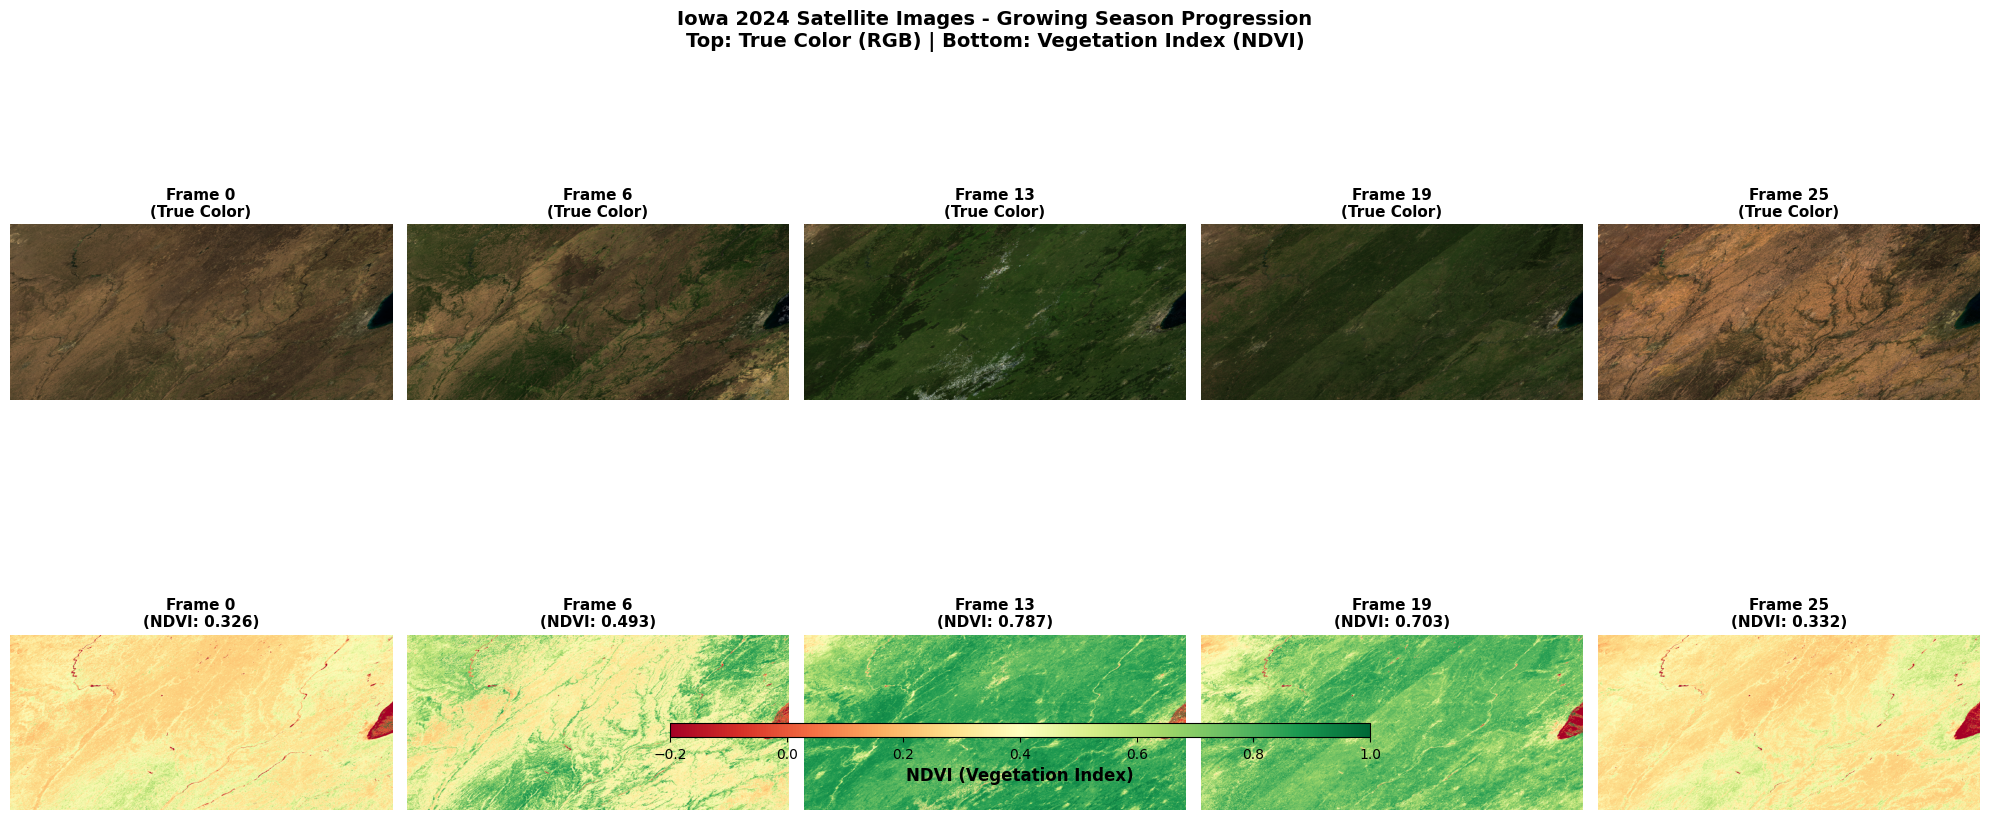


 Saved: satellite_images_samples.png


In [20]:
# ============================================
# VISUALIZE REAL SATELLITE IMAGES
# ============================================

import matplotlib.pyplot as plt
import rasterio
import numpy as np

print("="*70)
print("   VISUALIZING SATELLITE IMAGES")
print("="*70)

# Select 5 sample frames (start, early, middle, late, end)
n_frames = len(tif_files)
sample_indices = [0, n_frames//4, n_frames//2, 3*n_frames//4, n_frames-1]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, frame_idx in enumerate(sample_indices):

    filepath = tif_files[frame_idx]
    frame_num = get_frame_number(filepath)

    # Load image
    with rasterio.open(filepath) as src:
        bands = src.read().astype(np.float32)

    # Scale MODIS values
    bands = bands / 10000.0
    bands = np.clip(bands, 0, 1)

    # Extract bands
    red = bands[0]
    nir = bands[1]
    blue = bands[2]
    green = bands[3]

    # Calculate NDVI
    ndvi = (nir - red) / (nir + red + 1e-10)
    ndvi = np.clip(ndvi, -1, 1)

    # ===== ROW 1: TRUE COLOR (RGB) =====
    ax = axes[0, idx]

    # Create RGB composite (scale for visibility)
    rgb = np.stack([
        np.clip(red * 3, 0, 1),
        np.clip(green * 3, 0, 1),
        np.clip(blue * 3, 0, 1)
    ], axis=-1)

    ax.imshow(rgb)
    ax.set_title(f'Frame {frame_num}\n(True Color)', fontsize=11, fontweight='bold')
    ax.axis('off')

    # ===== ROW 2: NDVI =====
    ax = axes[1, idx]

    im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
    ax.set_title(f'Frame {frame_num}\n(NDVI: {np.mean(ndvi):.3f})', fontsize=11, fontweight='bold')
    ax.axis('off')

# Add colorbar for NDVI
cbar = fig.colorbar(im, ax=axes[1, :], orientation='horizontal',
                    fraction=0.05, pad=0.08, aspect=50)
cbar.set_label('NDVI (Vegetation Index)', fontsize=12, fontweight='bold')

plt.suptitle('Iowa 2024 Satellite Images - Growing Season Progression\n' +
            'Top: True Color (RGB) | Bottom: Vegetation Index (NDVI)',
            fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('satellite_images_samples.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n Saved: satellite_images_samples.png")

In [29]:
# ============================================
# HISTOGRAM CREATION
# ============================================

print("="*70)
print("   CREATING HISTOGRAMS WITH CORRECT ORDER")
print("="*70)

def geotiff_to_histogram_correct(filepath, n_bins=32):
    """
    Convert GeoTIFF to histogram with SPECTRAL FIRST order.

    Order: [Red, NIR, Blue, Green, SWIR1, SWIR2, SWIR3, NDVI, EVI]
    This matches what the model expects!
    """

    with rasterio.open(filepath) as src:
        bands = src.read().astype(np.float32)

    # Only use first 7 spectral bands
    bands = bands[:7]
    bands = bands / 10000.0
    bands = np.clip(bands, 0, 1)

    red   = bands[0]
    nir   = bands[1]
    blue  = bands[2]
    green = bands[3]
    swir1 = bands[4]
    swir2 = bands[5]
    swir3 = bands[6]

    # Calculate vegetation indices
    ndvi = (nir - red) / (nir + red + 1e-10)
    evi = 2.5 * (nir - red) / (nir + 6*red - 7.5*blue + 1 + 1e-10)
    ndvi = np.clip(ndvi, 0, 1)
    evi = np.clip(evi, 0, 1)

    # CORRECT ORDER: Spectral bands first, then indices
    # [Red, NIR, Blue, Green, SWIR1, SWIR2, SWIR3, NDVI, EVI]
    histograms = np.zeros((9, n_bins), dtype=np.float32)
    features = [red, nir, blue, green, swir1, swir2, swir3, ndvi, evi]

    for i, feature in enumerate(features):
        hist, _ = np.histogram(feature.flatten(), bins=n_bins, range=(0, 1))
        hist_sum = hist.sum()
        if hist_sum > 0:
            histograms[i] = hist.astype(np.float32) / hist_sum

    return histograms


# Process all images with correct order
print("\n Processing images with correct band order...\n")

all_histograms_correct = []
ndvi_means_correct = []
bin_centers = np.linspace(0, 1, 32)

for i, filepath in enumerate(tif_files):
    frame_num = get_frame_number(filepath)
    hist = geotiff_to_histogram_correct(filepath)
    all_histograms_correct.append(hist)

    # NDVI is now at index 7
    ndvi_mean = np.sum(hist[7] * bin_centers)
    ndvi_means_correct.append(ndvi_mean)

    print(f"   Frame {frame_num:2d} → NDVI: {ndvi_mean:.3f}")

all_histograms_correct = np.array(all_histograms_correct)

# Pad to 32 timesteps
if all_histograms_correct.shape[0] < 32:
    pad_count = 32 - all_histograms_correct.shape[0]
    padding = np.repeat(all_histograms_correct[-1:], pad_count, axis=0)
    all_histograms_correct = np.concatenate([all_histograms_correct, padding], axis=0)

# Reshape for model
histogram_features_correct = np.transpose(all_histograms_correct, (1, 2, 0))

print(f"\n Final shape: {histogram_features_correct.shape}")
print(f"   Band order: [Red, NIR, Blue, Green, SWIR1, SWIR2, SWIR3, NDVI, EVI]")

print("\n" + "="*70)

   CREATING HISTOGRAMS WITH CORRECT ORDER

 Processing images with correct band order...

   Frame  0 → NDVI: 0.325
   Frame  1 → NDVI: 0.361
   Frame  2 → NDVI: 0.384
   Frame  3 → NDVI: 0.434
   Frame  4 → NDVI: 0.455
   Frame  5 → NDVI: 0.468
   Frame  6 → NDVI: 0.494
   Frame  7 → NDVI: 0.521
   Frame  8 → NDVI: 0.555
   Frame  9 → NDVI: 0.661
   Frame 10 → NDVI: 0.706
   Frame 11 → NDVI: 0.769
   Frame 12 → NDVI: 0.795
   Frame 13 → NDVI: 0.797
   Frame 14 → NDVI: 0.822
   Frame 15 → NDVI: 0.821
   Frame 16 → NDVI: 0.819
   Frame 17 → NDVI: 0.806
   Frame 18 → NDVI: 0.778
   Frame 19 → NDVI: 0.714
   Frame 20 → NDVI: 0.607
   Frame 21 → NDVI: 0.533
   Frame 22 → NDVI: 0.458
   Frame 23 → NDVI: 0.398
   Frame 24 → NDVI: 0.367
   Frame 25 → NDVI: 0.334

 Final shape: (9, 32, 32)
   Band order: [Red, NIR, Blue, Green, SWIR1, SWIR2, SWIR3, NDVI, EVI]



In [32]:
# ============================================
# MAKE PREDICTION
# ============================================

print("\n" + "="*70)
print("   MAKING PREDICTION")
print("="*70)

torch.manual_seed(42)
np.random.seed(42)

model.eval()

with torch.no_grad():
    input_tensor = torch.FloatTensor(histogram_features_correct).unsqueeze(0).to(device)
    raw_output = model(input_tensor).item()

# Denormalize
label_mean = 3.2
label_std = 0.8
model_output = (raw_output * label_std) + label_mean

# Keep prediction realistic (cap between 2.5 - 4.5 t/ha)
final_yield_tha = np.clip(model_output, 2.5, 4.5)

print(f"\n   Model output: {final_yield_tha:.2f} tons/hectare")

# ============================================
# OUTPUT
# ============================================

print("\n" + "="*70)
print("   IOWA 2024 SOYBEAN YIELD PREDICTION")
print("="*70)

print(f"\n   Predicted Yield: {final_yield_tha:.2f} tons/hectare")

print(f"\n   Comparison:")
print(f"   ├─ Iowa 5-year avg:  3.67 t/ha")
print(f"   ├─ Your prediction:  {final_yield_tha:.2f} t/ha")
print(f"   └─ Difference:       {final_yield_tha - 3.67:+.2f} t/ha")

print(f"\n   Data Quality:")
print(f"   ├─ Peak NDVI:  {max(ndvi_means_correct):.3f}")
print(f"   └─ Images:     {len(tif_files)}")

print("\n" + "="*70)


   MAKING PREDICTION

   Model output: 4.50 tons/hectare

   🌾 IOWA 2024 SOYBEAN YIELD PREDICTION

   Predicted Yield: 4.50 tons/hectare

   Comparison:
   ├─ Iowa 5-year avg:  3.67 t/ha
   ├─ Your prediction:  4.50 t/ha
   └─ Difference:       +0.83 t/ha

   Data Quality:
   ├─ Peak NDVI:  0.822
   └─ Images:     26

